In [120]:
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from pandas.tseries.offsets import DateOffset

In [100]:
num_dates = 730
start_year = 2024

daily_counts = np.random.randint(1750, 2500, size=730) #array of 730 random numbers
dates_column1 = pd.date_range(start=f"1/1/{start_year}", periods=num_dates)
dates = np.repeat(dates_column1, daily_counts) #repeats each 
df = pd.DataFrame({'date': dates})
df.shape

(1553837, 1)

In [102]:
df['month'] = pd.DatetimeIndex(df['date']).month
df['day_of_week'] = pd.DatetimeIndex(df['date']).dayofweek
df['hour'] = np.random.normal(loc=13, scale=4, size=len(df)).clip(0, 23).astype(int)
#this hour line generates random number cetered around 13:00 with most values falling within plus or minus 4 hours of that time
#clip(0,23) cuts off anythign below 0 or above 23
df['urgency'] = np.random.choice([0,1,2], p=[0.5,0.35,0.15], size=len(df)) #where 0 = 2-3 days delivery, 1 = next day delivery and 2 = same day delivery
df['distance'] = np.random.exponential(scale = 400, size = len(df)).clip(50,2500).astype(int)
#In an exponential distribution, scale is the average. ths line applies random numbers in an exponential distribution with average 400km
# capped at 2500 max and 50 km min
def assign_vehicle(distance):
    if distance < 200:
        return np.random.choice([0,1,2], p = [0.70,0.20,0.10]) #Where 0 = van, 1 = small truck, 2 = large truck.
    elif distance < 800:
        return np.random.choice([0,1,2], p = [0.20,0.50,0.30])
    else:
        return np.random.choice([0,1,2], p = [0.10,0.30,0.60])
df['vehicle_type'] = df['distance'].apply(assign_vehicle) 

#Function for available carriers 
def assign_carriers(row):
    vehicle_type = row['vehicle_type']
    hour = row['hour']
    if vehicle_type == 0:
        if hour < 4:
            return random.randint(3, 10)  # half the normal range
        else:
            return random.randint(5, 20)
    elif vehicle_type == 1:
        if hour < 4:
            return random.randint(2, 5)  # half the normal range
        else:
            return random.randint(3, 15)
    else:
        if hour < 4:
            return random.randint(1, 4)  # half the normal range
        else:
            return random.randint(1, 8)
df['available_carriers'] = df.apply(assign_carriers, axis=1)

# for fuel prices, every shipment on the same day should have the same fuel prices. The fuel price depends on the date
unique_dates = df['date'].unique()

#base fuel price for each date
fuel_dict={}
for date in unique_dates:
    month_num = pd.Timestamp(date).month
    year = pd.Timestamp(date).year

    if year == 2024:
        fuel_dict[date] = round(1.40 + np.random.normal(0,0.03),2)
    elif year == 2025 and month_num <=3:
        fuel_dict[date] = round(1.55 + np.random.normal(0,0.03),2)
    else:
        fuel_dict[date] = round(1.85 + np.random.normal(0,0.04),2)

df['fuel_price'] = df['date'].map(fuel_dict)

#Value should be at least somehwta correlated with vehicle type. Usually larger vehicle might carry insdutrial parts worth more (reasonable assumption)

def assign_value(vehicle_type):
    if vehicle_type == 0:
        value = np.random.exponential(scale=4000)
        value = max(1000, min(value, 50000))
        return round(value,2)
    elif vehicle_type == 1:
        value = np.random.exponential(scale=15000)
        value = max(5000, min(value, 150000))
        return round(value,2)
    else:
        value = np.random.exponential(scale=25000)
        value = max(10000, min(value, 500000))
        return round(value,2)
df['cargo_value'] = df['vehicle_type'].apply(assign_value) 

# TO EStIMATE TARGET

def calculate_quote(row):
    base = 150
    # Distance: €1.80 per km (premium freight)
    distance_cost = row['distance'] * 1.80
    # Urgency: big jumps for faster delivery
    urgency_cost = row['urgency']*300 # 0=€0, next-day=€300, same-day=€600
    # Vehicle type: bigger vehicle = more expensive
    vehicle_cost = row['vehicle_type'] * 200  # van=€0, small=€200, large=€400
    # Fuel: multiplier on the distance cost
    fuel_adjustment = distance_cost * (row['fuel_price'] - 1.30) * 0.5
    # Cargo value: insurance component, ~1% of cargo value
    insurance = row['cargo_value'] * 0.01
    # Carrier availability: more carriers = lower price
    carrier_discount = row['available_carriers'] * 12
    # Night premium: shipments between 10pm-6am cost more
    night_premium = 150 if (row['hour'] >= 22 or row['hour'] <= 6) else 0
    # Weekend premium
    weekend_premium = 100 if row['day_of_week'] >= 5 else 0
    # August premium (vacation season)
    august_premium = 120 if row['month'] == 8 else 0
    quote = (base + distance_cost + urgency_cost + vehicle_cost 
             + fuel_adjustment + insurance - carrier_discount 
             + night_premium + weekend_premium + august_premium)
    
    # Add some random noise so the model has something to learn
    noise = np.random.normal(0, quote * 0.05)
    quote = max(150, quote + noise)
    
    return round(quote, 2)
    
df['quote'] = df.apply(calculate_quote, axis=1)
df

,date,month,day_of_week,hour,urgency,distance,vehicle_type,available_carriers,fuel_price,cargo_value,quote
0,2024-01-01,1,0,14,1,452,0,19,1.42,4093.82,1167.98
1,2024-01-01,1,0,13,1,183,1,3,1.42,12988.43,1061.92
2,2024-01-01,1,0,17,0,204,1,5,1.42,5889.56,682.51
3,2024-01-01,1,0,12,0,72,0,17,1.42,1326.47,150.00
4,2024-01-01,1,0,11,0,50,1,8,1.42,13443.52,503.30
...,...,...,...,...,...,...,...,...,...,...,...
1553832,2025-12-30,12,1,10,0,80,0,5,1.86,1602.07,259.96
1553833,2025-12-30,12,1,14,0,443,1,5,1.86,5000.00,1358.19
1553834,2025-12-30,12,1,11,0,151,0,17,1.86,3238.84,323.05
1553835,2025-12-30,12,1,19,0,115,0,7,1.86,3222.18,353.18


In [103]:
df['quote'].describe() 

count    1.553837e+06
mean     1.431476e+03
std      1.006746e+03
min      1.500000e+02
25%      6.844700e+02
50%      1.229860e+03
75%      1.909420e+03
max      8.706920e+03
Name: quote, dtype: float64

In [104]:
print(df.shape)
print(df.dtypes)
print(df.describe())

(1553837, 11)
date                  datetime64[ns]
month                          int32
day_of_week                    int32
hour                           int32
urgency                        int32
distance                       int32
vehicle_type                   int32
available_carriers             int64
fuel_price                   float64
cargo_value                  float64
quote                        float64
dtype: object
                                date         month   day_of_week  \
count                        1553837  1.553837e+06  1.553837e+06   
mean   2024-12-29 10:41:32.068344320  6.513388e+00  2.993571e+00   
min              2024-01-01 00:00:00  1.000000e+00  0.000000e+00   
25%              2024-07-01 00:00:00  4.000000e+00  1.000000e+00   
50%              2024-12-28 00:00:00  7.000000e+00  3.000000e+00   
75%              2025-06-29 00:00:00  9.000000e+00  5.000000e+00   
max              2025-12-30 00:00:00  1.200000e+01  6.000000e+00   
std                  

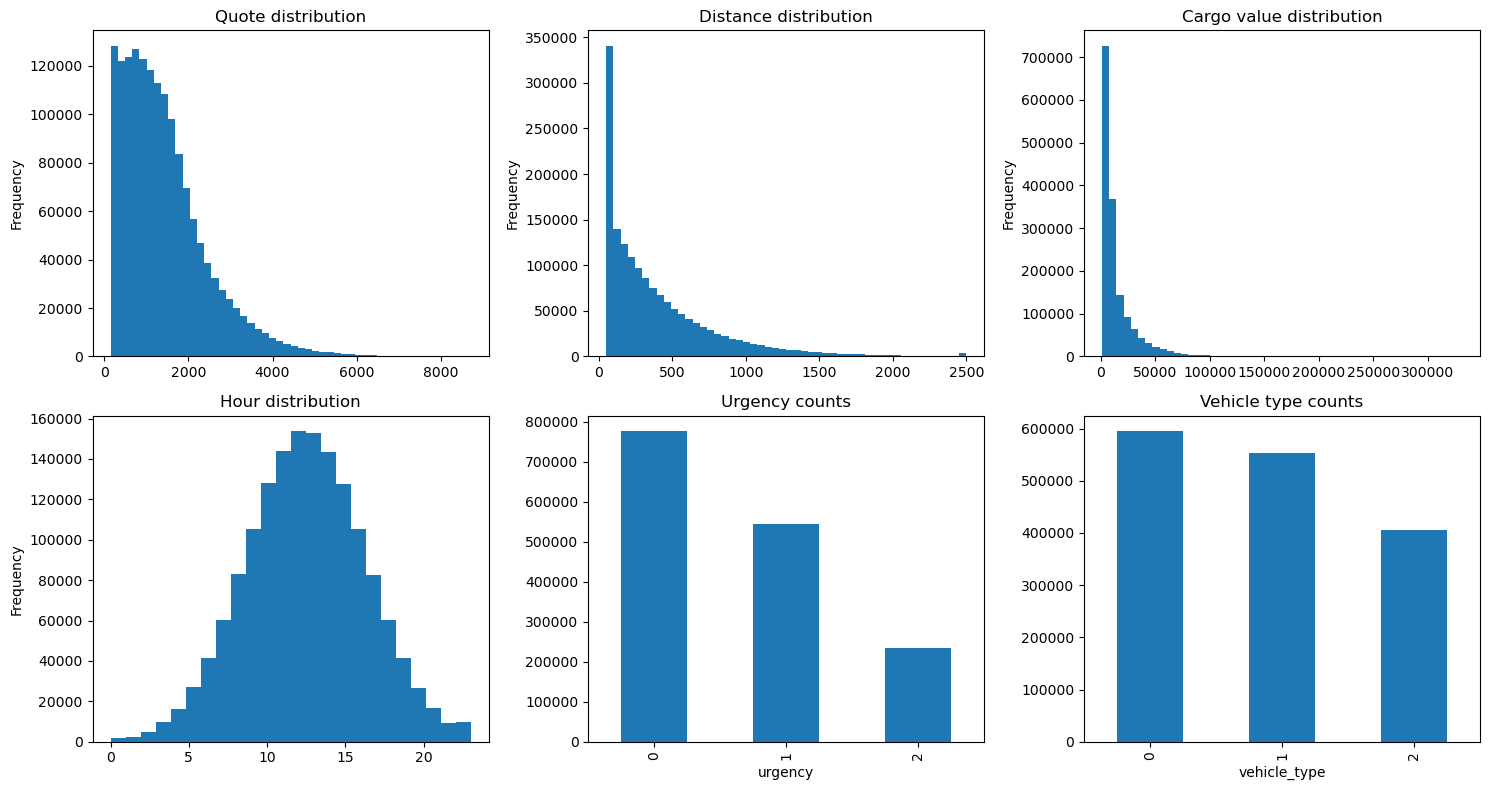

In [105]:
#Distribution check
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

df['quote'].plot(kind='hist', bins=50, ax=axes[0,0], title='Quote distribution')
df['distance'].plot(kind='hist', bins=50, ax=axes[0,1], title='Distance distribution')
df['cargo_value'].plot(kind='hist', bins=50, ax=axes[0,2], title='Cargo value distribution')
df['hour'].plot(kind='hist', bins=24, ax=axes[1,0], title='Hour distribution')
df['urgency'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], title='Urgency counts')
df['vehicle_type'].value_counts().sort_index().plot(kind='bar', ax=axes[1,2], title='Vehicle type counts')

plt.tight_layout()
plt.show()

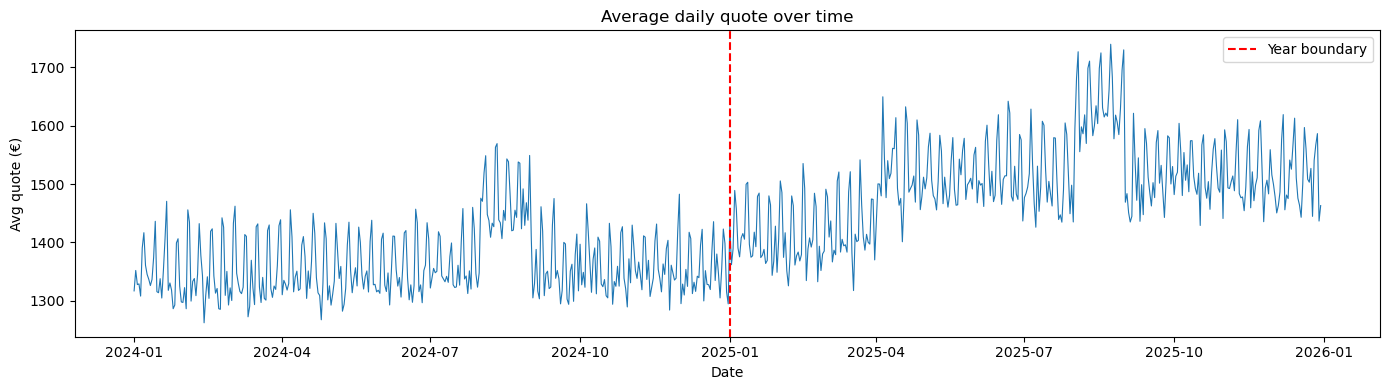

In [106]:
daily_avg = df.groupby('date')['quote'].mean()
plt.figure(figsize=(14, 4))
plt.plot(daily_avg.index, daily_avg.values, linewidth=0.8)
plt.axvline(pd.Timestamp('2025-01-01'), color='red', 
            linestyle='--', label='Year boundary')
plt.title('Average daily quote over time')
plt.xlabel('Date')
plt.ylabel('Avg quote (€)')
plt.legend()
plt.tight_layout()
plt.show()

In [107]:
# we see the spike premium and the fuel adjustment after march 2025 which icnreased to 1.85

In [108]:
df['year'] = df['date'].dt.year
print(df.groupby('year')['quote'].describe().round(2))
print("\nMean fuel price by year:")
print(df.groupby('year')['fuel_price'].mean().round(3))

         count     mean      std    min     25%      50%      75%      max
year                                                                      
2024  783670.0  1363.11   939.37  150.0  661.51  1182.68  1820.96  7851.68
2025  770167.0  1501.04  1066.48  150.0  709.06  1282.91  2000.50  8706.92

Mean fuel price by year:
year
2024    1.398
2025    1.777
Name: fuel_price, dtype: float64


In [203]:
### Traning the model
features = ['month', 'day_of_week', 'hour', 'urgency', 'distance', 
            'vehicle_type', 'available_carriers', 'fuel_price', 'cargo_value']
results = []
feature_importance = []
test_months = df[df['year'] == 2025]['date'].dt.to_period('M').unique()

for month in test_months:
    month_start = month.to_timestamp()
    window_start = month_start - DateOffset(months=6)
    window_end = month_start  # up to but not including current month
    #splitting the dataframe by window start and window end
    train_window = df.loc[(df['date'] >= window_start) & (df['date'] < window_end)]
    X_train = train_window[features]
    y_train = train_window['quote']
    #for the test side
    current_month = df[df['date'].dt.to_period('M') == month]
    X_test = current_month[features]
    y_test = current_month['quote']

    model = XGBRegressor(n_estimators = 100, random_state = 42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
#############
    importance = pd.Series(model.feature_importances_,index = features).sort_values(ascending = True)
    feature_importance.append(importance)
    
############
    
    mae = mean_absolute_error(y_test, preds)
    results.append({'month': month, 'mae': mae})
    print(f"{month} — MAE: €{mae:.2f}")

    if month == test_months[-1]:
        final_model = model
results_df = pd.DataFrame(results)
avg_importance = pd.DataFrame(feature_importance).mean()


2025-01 — MAE: €69.60
2025-02 — MAE: €61.69
2025-03 — MAE: €61.75
2025-04 — MAE: €94.02
2025-05 — MAE: €66.68
2025-06 — MAE: €66.86
2025-07 — MAE: €65.12
2025-08 — MAE: €134.18
2025-09 — MAE: €132.61
2025-10 — MAE: €66.51
2025-11 — MAE: €66.03
2025-12 — MAE: €65.67


In [204]:
results_df.head(12)

,month,mae
0,2025-01,69.601020
1,2025-02,61.685250
2,2025-03,61.749258
3,2025-04,94.016063
4,2025-05,66.677583
5,2025-06,66.860821
6,2025-07,65.117151
7,2025-08,134.175943
8,2025-09,132.613480
9,2025-10,66.507102


In [205]:
#### NAIVE MODEL FOR COMPARISON

In [206]:
train_naive = df[df['year'] == 2024]
test_naive  = df[df['year'] == 2025]

X_train_naive = train_naive[features]
y_train_naive = train_naive['quote']
X_test_naive  = test_naive[features]
y_test_naive  = test_naive['quote']

naive_model = XGBRegressor(n_estimators=100, random_state=42)
naive_model.fit(X_train_naive, y_train_naive)
naive_preds = naive_model.predict(X_test_naive)
mae = mean_absolute_error(y_test_naive, naive_preds)
print(f"Naive MAE: €{mean_absolute_error(y_test_naive, naive_preds):.2f}")

Naive MAE: €119.05


In [207]:
### VISUALIZING THE COMPARISON

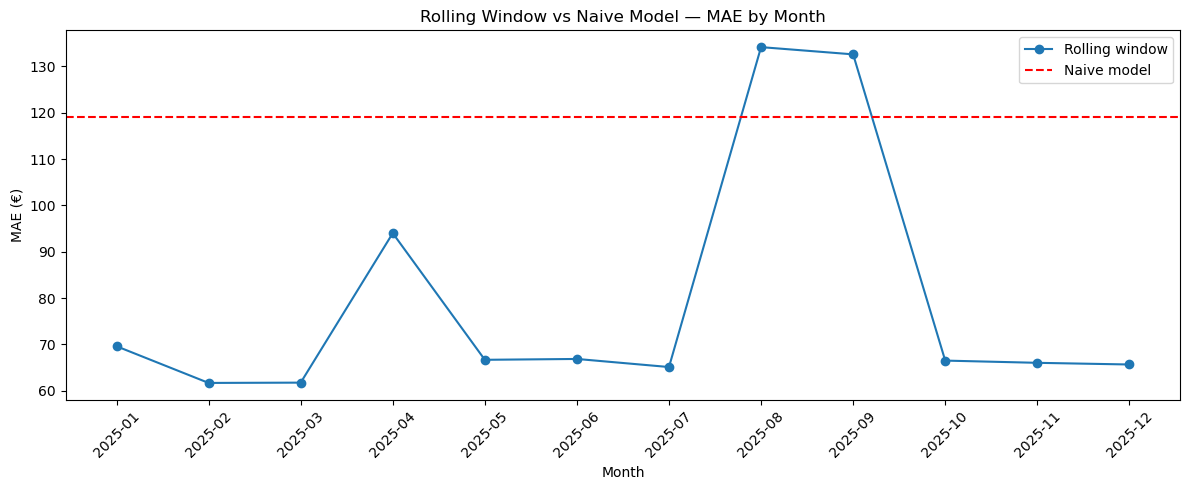

In [208]:
results_df['month_str'] = results_df['month'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(results_df['month_str'], results_df['mae'], marker='o', label='Rolling window')
plt.axhline(y=119.05, color='red', linestyle='--', label='Naive model')
plt.xlabel('Month')
plt.ylabel('MAE (€)')
plt.title('Rolling Window vs Naive Model — MAE by Month')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

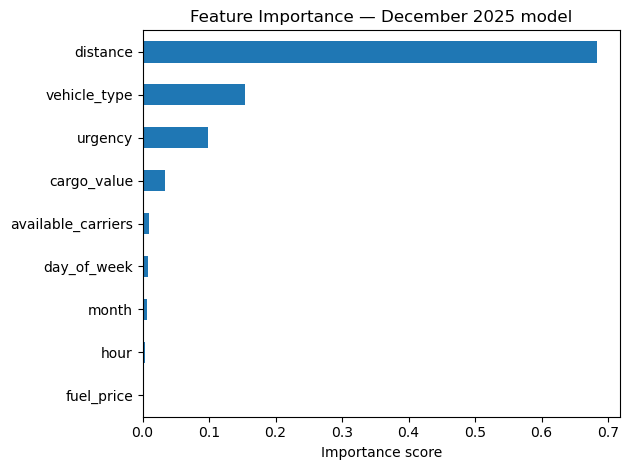

In [209]:
#Feature Importance
importance.plot(kind='barh')
plt.title('Feature Importance — December 2025 model')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

In [219]:
#Getting a prediction on a pretend shipment with both naive model and rolling window model
#NAIVE MODEL
new_shipment = pd.DataFrame([{
    'month': 4,
    'day_of_week': 3,
    'hour': 14,
    'urgency': 1,
    'distance': 450,
    'vehicle_type': 1,
    'available_carriers': 8,
    'fuel_price': 1.85,
    'cargo_value': 12000
}])

predicted_quote = naive_model.predict(new_shipment)
print(f"Predicted quote: €{predicted_quote[0]:.2f}")

Predicted quote: €1577.16


In [221]:
#Rolling model
new_shipment = pd.DataFrame([{
    'month': 4,
    'day_of_week': 3,
    'hour': 14,
    'urgency': 1,
    'distance': 450,
    'vehicle_type': 1,
    'available_carriers': 8,
    'fuel_price': 1.85,
    'cargo_value': 12000
}])

predicted_quote = final_model.predict(new_shipment)
print(f"Predicted quote: €{predicted_quote[0]:.2f}")

Predicted quote: €1708.34
